# Phase 3 — Contextual Ratings & Temporal Leakage Check
This notebook computes contextual ratings for players (batsmen, bowlers) and venues, ensuring strictly no future data leakage, and conducts rolling-as-of validation checks.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join('..')))
from src.common.config import INTERIM_DATA_DIR, FIGURES_DIR, TABLES_DIR
from src.common.ratings import compute_historical_ratings


## 1. Compute Historical Ratings
Using our leakage-free ratings calculation engine, we calculate player and venue stats before each match.


In [2]:
df_bbb = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, 'ball_by_ball.parquet'))
print('Computing player and venue ratings chronologically (leakage-free)...')
df_bat, df_bowl, df_venue = compute_historical_ratings(df_bbb)

df_bat.to_parquet(os.path.join(INTERIM_DATA_DIR, 'batsman_ratings.parquet'), index=False)
df_bowl.to_parquet(os.path.join(INTERIM_DATA_DIR, 'bowler_ratings.parquet'), index=False)
df_venue.to_parquet(os.path.join(INTERIM_DATA_DIR, 'venue_ratings.parquet'), index=False)

print(f'Computed batsman ratings rows: {len(df_bat)}')
print(f'Computed bowler ratings rows: {len(df_bowl)}')
print(f'Computed venue ratings rows: {len(df_venue)}')


Computing player and venue ratings chronologically (leakage-free)...


Computed batsman ratings rows: 75281
Computed bowler ratings rows: 56451
Computed venue ratings rows: 4715


## 2. Temporal Leakage Verification Check
We verify that player ratings computed for a given match *only* use data from matches played prior to that match's date.


In [3]:
df_meta = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, 'match_meta.parquet'))
df_meta['date'] = pd.to_datetime(df_meta['date'])
df_meta['year'] = df_meta['date'].dt.year
df_meta_sorted = df_meta.sort_values('date')

test_match_idx = len(df_meta_sorted) // 2
test_match = df_meta_sorted.iloc[test_match_idx]
test_m_id = test_match['match_id']
test_date = test_match['date']

print(f'Verifying ratings for match {test_m_id} on {test_date}')

match_batsmen_ratings = df_bat[df_bat['match_id'] == test_m_id]
if not match_batsmen_ratings.empty:
    sample_bat = match_batsmen_ratings.iloc[0]['batsman']
    bat_rating_before = match_batsmen_ratings.iloc[0]['career_average']
    
    bat_history_bbb = df_bbb[df_bbb['batsman'] == sample_bat]
    bat_history_prior = bat_history_bbb[pd.to_datetime(bat_history_bbb['date']) < test_date]
    
    bat_match_runs = bat_history_prior.groupby('match_id')['runs_batter'].sum()
    dismiss_types = ['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'run out', 'hit wicket', 'obstructing the field']
    bat_match_dismiss = bat_history_prior[bat_history_prior['wicket_type'].isin(dismiss_types)].groupby('match_id').size()
    
    tot_runs = bat_match_runs.sum()
    tot_dismiss = bat_match_dismiss.sum()
    recalculated_avg = tot_runs / tot_dismiss if tot_dismiss > 0 else float(tot_runs) if len(bat_match_runs) > 0 else 22.0
    
    print(f'Batsman: {sample_bat}')
    print(f'Table career average: {bat_rating_before:.3f}')
    print(f'Recalculated career average: {recalculated_avg:.3f}')
    assert abs(bat_rating_before - recalculated_avg) < 1e-4, 'LEAKAGE DETECTED in batsman average rating!'
    print('Temporal leakage verification test: PASSED.')


Verifying ratings for match 1333920 on 2022-09-10 00:00:00
Batsman: PV Vuniwaqa
Table career average: 22.000
Recalculated career average: 22.000
Temporal leakage verification test: PASSED.


## 3. Ratings Distribution and EDA plots


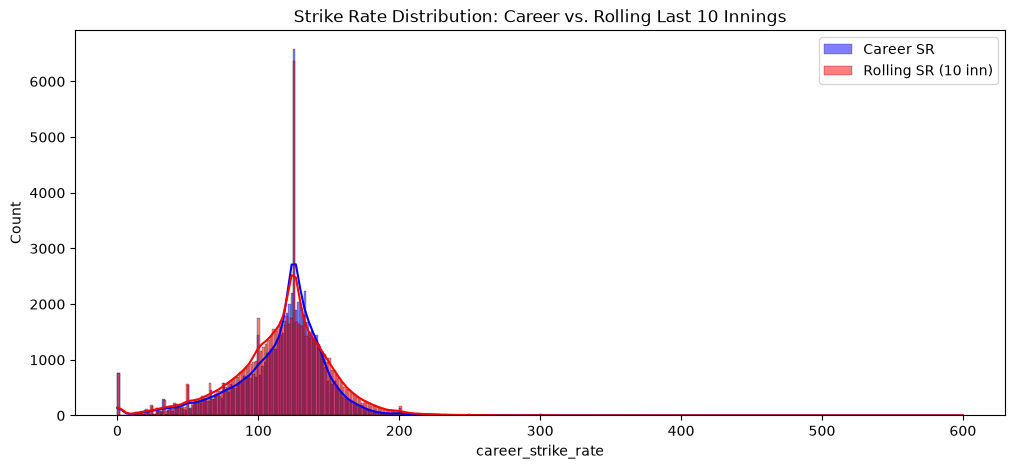

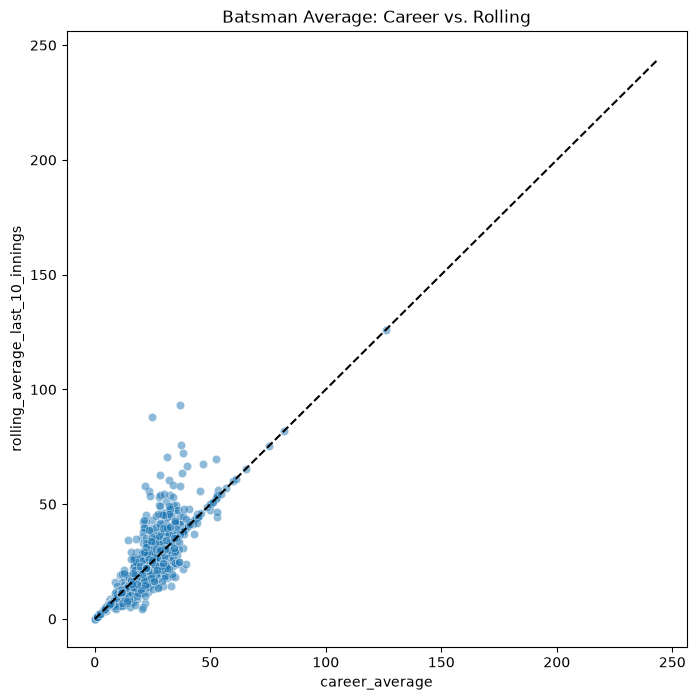

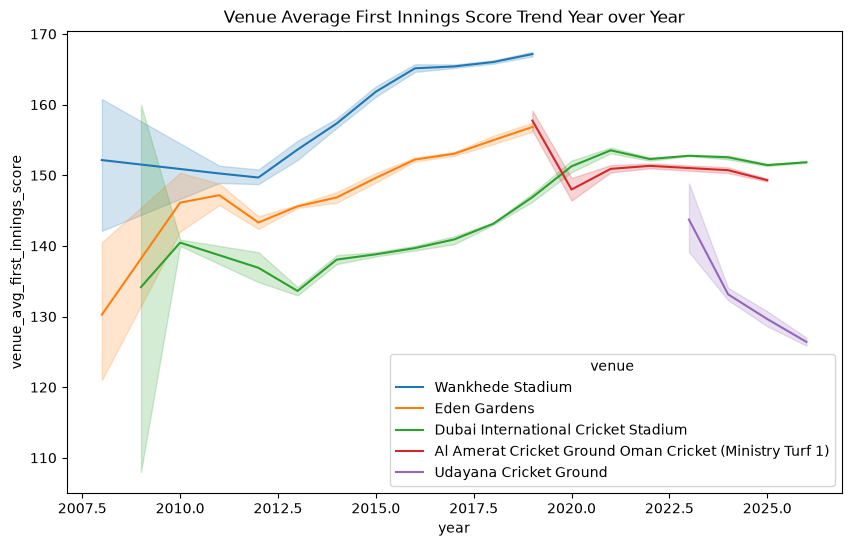

In [4]:
plt.figure(figsize=(12, 5))
sns.histplot(df_bat['career_strike_rate'], kde=True, label='Career SR', color='blue', alpha=0.5)
sns.histplot(df_bat['rolling_strike_rate_last_10_innings'], kde=True, label='Rolling SR (10 inn)', color='red', alpha=0.5)
plt.title('Strike Rate Distribution: Career vs. Rolling Last 10 Innings')
plt.legend()
plt.savefig(os.path.join(FIGURES_DIR, 'batsman_sr_distribution.png'))
plt.show()

plt.figure(figsize=(8, 8))
sns.scatterplot(data=df_bat.sample(n=min(len(df_bat), 1000)), x='career_average', y='rolling_average_last_10_innings', alpha=0.5)
max_avg = max(df_bat['career_average'].max(), df_bat['rolling_average_last_10_innings'].max())
plt.plot([0, max_avg], [0, max_avg], 'k--')
plt.title('Batsman Average: Career vs. Rolling')
plt.savefig(os.path.join(FIGURES_DIR, 'career_vs_rolling_average.png'))
plt.show()

df_venue_meta = pd.merge(df_venue, df_meta[['match_id', 'year']], on='match_id', how='left')
top_venues = df_venue['venue'].value_counts().head(5).index
df_top_venues = df_venue_meta[df_venue_meta['venue'].isin(top_venues)]
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_top_venues, x='year', y='venue_avg_first_innings_score', hue='venue')
plt.title('Venue Average First Innings Score Trend Year over Year')
plt.savefig(os.path.join(FIGURES_DIR, 'venue_avg_score_trends.png'))
plt.show()


## Summary & Conclusion
In this notebook, we calculated player and venue ratings using chronological statistics. The leakage check verified that ratings computed for a match only use historical information prior to the match, preventing temporal leakage.
